In [93]:
# Import necessary libraries
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf


In [94]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train.shape # 60000 images of size 28X28

(60000, 28, 28)

## Data Augmentation 

In [95]:
# Normalize and expand dims for Keras data augmentation
first_image = x_train[0]
# Normalize pixel values to [0, 1]
normalise_image = first_image.astype('float32')/255.0
normalise_image = np.expand_dims(normalise_image, axis = (0,-1)) # expand to 1 x 28 x 28 x 1
normalise_image.shape 


(1, 28, 28, 1)

Define Rotation layer

In [96]:
# Random rotation augmentation
rotation_layer = keras.layers.RandomRotation(factor = 0.1)
rotated_image = rotation_layer(normalise_image)

Text(0.5, 1.0, 'Rotated image')

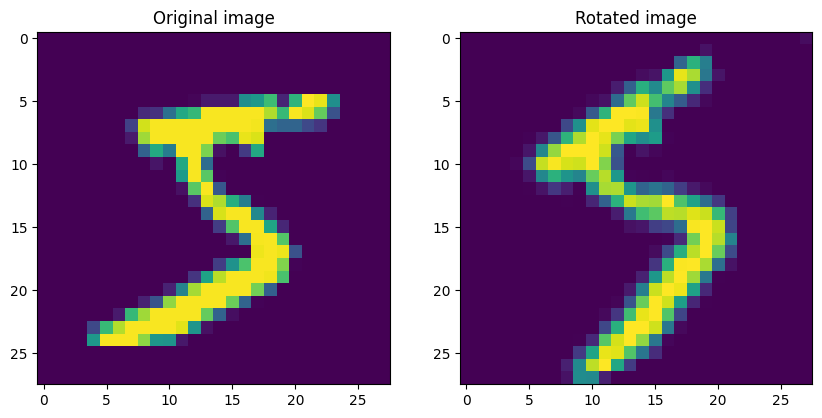

In [97]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(rotated_image.numpy().squeeze())
plt.title('Rotated image')



Random Translation layer 

In [98]:
# Random translation augmentation
translation_layer = keras.layers.RandomTranslation(height_factor=0.5, width_factor=0.5)
translated_image = translation_layer(normalise_image)

Text(0.5, 1.0, 'Translated image')

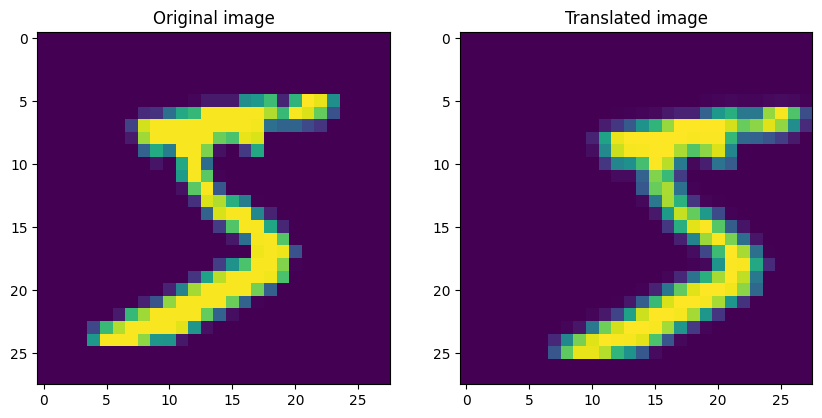

In [99]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(translated_image.numpy().squeeze())
plt.title('Translated image')

## Feature extraction using PCA


To apply Principal Component Analysis, we have to centralise the data

In [114]:
from sklearn.decomposition import PCA
# Flatten images from 28x28 to 784

x_train_reshaped = tf.cast(tf.reshape(x_train, [-1, 784]), tf.float32)
pca = PCA(n_components=50)
pca.fit(x_train_reshaped)

x_train_pca = pca.transform(x_train_reshaped)



In [101]:

print("Original data shape:", x_train.shape)
print("PCA projected shape:", x_pca.shape)

Original data shape: (60000, 28, 28)
PCA projected shape: (60000, 50)


## Apply LBP and HOG

In [102]:
from skimage.feature import local_binary_pattern
from skimage import color
# Extract Local Binary Pattern features for an array of images
def extract_LBP_features(images):
    lbp_features = []
    for image in images:
# Compute uniform LBP
        lbp_image = local_binary_pattern(image, P=8 , R = 2, method = 'uniform')
        # since lbp_image in of the shape 28x28 , we flatten it
        lbp_features.append(lbp_image.flatten())

    return np.array(lbp_features)

x_train_lbp = extract_LBP_features(x_train)
print(f'Original shape: {x_train.shape}')
print(f'LBP feature shape: {x_train_lbp.shape}')


Original shape: (60000, 28, 28)
LBP feature shape: (60000, 784)


Text(0.5, 1.0, 'LBP image')

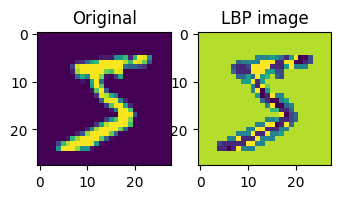

In [103]:
image = x_train[0]
lbp = local_binary_pattern(image, 8, 2 , method = 'uniform')
plt.figure(figsize = (10, 5))
plt.subplot(1,5, 1)
plt.imshow(image)
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(lbp)
plt.title('LBP image')

## HOG (Histogram  of Oriented Gradients )

In [104]:
from skimage.feature import hog

# Extract Histogram of Oriented Gradients (HOG) features
def extract_hog_features(images):
    hog_features = []
    for image in images:
# Compute HOG features
        hog_image = hog(image, orientations=9,
                pixels_per_cell=(7, 7), 
                 cells_per_block=(2, 2), 
                 visualize=False)
        hog_features.append(hog_image)
    return np.array(hog_features)


In [105]:
x_train_hog = extract_hog_features(x_train)
print(f'Origial shape: {x_train.shape}')
print(f'Hog feature shape: {x_train_hog.shape}')

Origial shape: (60000, 28, 28)
Hog feature shape: (60000, 324)


In [106]:
from skimage import exposure
image = x_train[0]
# Compute HOG features
fd, hog_image = hog(image, orientations=8, pixels_per_cell=(7, 7), cells_per_block=(2, 2), visualize=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

Text(0.5, 1.0, 'HOG image')

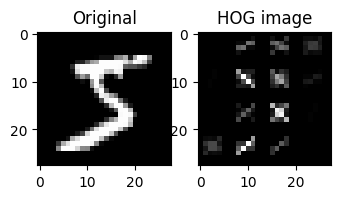

In [107]:
plt.figure(figsize = (10, 5))
plt.subplot(1,5, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(hog_image, cmap = 'gray')
plt.title('HOG image')

## Logistic Regression


In [108]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter= 1000)
logistic.fit(x_train_hog, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [109]:
from sklearn.metrics import accuracy_score
x_test_hog = extract_hog_features(x_test)
y_predicted = logistic.predict(x_test_hog)
print(f'accuracy score: {accuracy_score(y_predicted, y_test)}')


accuracy score: 0.9732


## Classification after feature extraction (Ex. Random forest)


In [118]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state = 42)
rf.fit(x_train_pca, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [115]:
from sklearn.decomposition import PCA
x_test_reshaped = tf.cast(tf.reshape(x_test, [-1, 784]), tf.float32)
x_test_pca = pca.transform(x_test_reshaped)

In [119]:
y_predicted = rf.predict(x_test_pca)
y_predicted

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [120]:
from sklearn.metrics import confusion_matrix, accuracy_score
print(f'Confusion matrix : {confusion_matrix(y_predicted, y_test)}')
print(f'Accuracy Score : {accuracy_score(y_predicted, y_test)}')

Confusion matrix : [[ 965    0    8    2    0    3    7    2    4    5]
 [   0 1119    0    0    0    1    2    7    0    5]
 [   2    1  979    7    5    3    2   19   10    3]
 [   0    4   12  958    1   17    0    1   18   11]
 [   1    0    5    0  934    4    5    4    9   22]
 [   3    0    0    9    3  848    3    1   16    6]
 [   5    6    3    0    9    5  937    0    5    2]
 [   1    1   11   10    1    1    0  969    6   13]
 [   2    4   14   19    3    4    2    2  898   10]
 [   1    0    0    5   26    6    0   23    8  932]]
Accuracy Score : 0.9539


## Bag of Words (BoW)